# 🏗️ Module 04 — Parameter-Efficient Fine-Tuning (PEFT)
## Fine-Tuning LLMs Without Breaking the Bank

**Series:** Practical ML Engineering — Module 4 of 6
**Prerequisites:** Modules 1–3 (Traditional ML, Deep Learning, Transfer Learning)
**Runtime:** ~8 minutes on CPU

---

> **The Central Question:**
> Full fine-tuning a 7B model requires **112 GB of GPU memory**.
> The best consumer GPU has 24 GB. A cloud A100 costs ~\$3/hour.
> How do enterprises **actually** fine-tune LLMs affordably?

**Answer:** Parameter-Efficient Fine-Tuning (PEFT) — train only 1% of the weights.

---

### 🎯 What You Will Learn
| Lesson | Topic |
|--------|-------|
| 1 | Why full fine-tuning is expensive (the math) |
| 2 | PEFT overview — the four main methods |
| 3 | LoRA — deep dive with math and code |
| 4 | HuggingFace PEFT library — hands-on |
| 5 | QLoRA — fine-tuning 7B on a gaming GPU |
| 6 | Prefix Tuning & Prompt Tuning |
| 7 | Enterprise decision guide — which method when |
| 8 | What fine-tuning actually changes |

### 🏢 Use Case: Legal Document Routing System
A law firm receives hundreds of documents daily. We build a classifier that routes each document to the correct department:
- **Contract** — NDAs, service agreements, vendor contracts
- **Litigation** — court filings, depositions, motions
- **Compliance** — regulatory filings, audit reports
- **IP** — patents, trademarks, copyright notices
- **HR** — employment agreements, termination letters


## 📖 Lesson 1 — The Problem: Full Fine-Tuning is Expensive

### Why does fine-tuning need so much memory?

When you *use* a model (inference), you only need to store the weights:

| Model | Parameters | Memory (Inference, FP32) |
|-------|-----------|--------------------------|
| BERT-base | 110 M | ~440 MB |
| GPT-2 | 1.5 B | ~6 GB |
| LLaMA-7B | 7 B | ~28 GB |
| GPT-4 (estimated) | ~1 T | ~4,000 GB |

**Rule of thumb:** 4 bytes per parameter (FP32) → 1B params ≈ 4 GB for inference.

---

### Training multiplies memory by 4–5×

During fine-tuning, PyTorch must store **four things** for every parameter:

```
1. The weight itself          →  4 bytes  (FP32)
2. The gradient               →  4 bytes  (same shape as weight)
3. Adam optimizer — momentum  →  4 bytes  (same shape again)
4. Adam optimizer — variance  →  4 bytes  (same shape again)
                              ─────────────────────
Total per parameter:          → 16 bytes  (4× inference)
```

### The 7B model math:
```
7,000,000,000 parameters × 16 bytes = 112,000,000,000 bytes = 112 GB
```

**No single consumer GPU can do this.** Even cloud A100s (80 GB) cannot fit it in one card.

| Model | Inference | Full Fine-Tune | Fits on... |
|-------|-----------|----------------|------------|
| BERT-base (110M) | 0.4 GB | ~1.8 GB | Any laptop GPU |
| GPT-2 (1.5B) | 6 GB | ~24 GB | RTX 3090 (barely) |
| LLaMA-7B | 28 GB | **112 GB** | 2× A100s minimum |
| GPT-3 (175B) | 700 GB | **2,800 GB** | ~35× A100s |
| GPT-4 (~1T est.) | ~4,000 GB | **~16,000 GB** | A data center |

### 📝 Note
This is why you hear about companies spending millions on fine-tuning runs.
Before PEFT methods existed (pre-2022), fine-tuning large models was only feasible
for well-funded labs. PEFT democratized LLM fine-tuning — you can now fine-tune
a 7B model on a **single RTX 3090 gaming GPU** (24 GB).


## 📖 Lesson 2 — The Solution: PEFT Overview

### The Core Idea

Instead of updating all 7 billion weights, **freeze most of them** and only train
a tiny number of new parameters — usually 0.1% to 1% of the total.

```
BEFORE (Full Fine-Tuning):
┌─────────────────────────────────────────────────────┐
│  ALL 7,000,000,000 weights  ← all updated each step │
└─────────────────────────────────────────────────────┘
        Memory: 112 GB        Training cost: $$$

AFTER (PEFT):
┌─────────────────────────────────────────────────────┐
│  6,930,000,000 weights  ← FROZEN, never touched      │
│      70,000,000 new params  ← only these are trained │
└─────────────────────────────────────────────────────┘
        Memory: ~6 GB         Training cost: $
```

The key insight: the large pre-trained model already "knows" language.
We just need to teach it **task-specific** adjustments — and those adjustments
are surprisingly small.

---

### The Four Main PEFT Approaches

| Method | Core Idea | Trainable Params | Memory Reduction | Quality | Complexity |
|--------|-----------|-----------------|------------------|---------|------------|
| **Full Fine-Tune** | Train everything | 100% | 0% (baseline) | Best | Low |
| **Adapter Layers** | Insert small bottleneck layers | ~0.5–3% | 60–70% | Very Good | Medium |
| **Prefix Tuning** | Prepend learned virtual tokens | ~0.1% | 80–90% | Good | Medium |
| **LoRA** | Low-rank decomposition of weight updates | ~0.1–1% | 70–85% | Very Good | Low |
| **QLoRA** | LoRA + 4-bit quantization of base model | ~0.1–1% | 90–95% | Good–Very Good | Medium |

### 📝 Note: Why Does This Work?
Research has shown that the *weight updates* needed for fine-tuning have
**low intrinsic rank** — meaning the important information lives in a small
subspace. PEFT methods exploit this by only learning that small subspace.
Think of it as: the model already knows the whole English language,
you just need to nudge it in a specific direction.


## 📖 Lesson 3 — LoRA Deep Dive

### The Layman Analogy
Imagine you own a factory (the pre-trained model) that makes general-purpose widgets.
You want it to also make specialized legal widgets.

- **Full fine-tuning** = shut down the factory, retool every machine, restart. Expensive.
- **LoRA** = keep the factory running as-is, just **bolt on a small side module**
  that handles the legal-specific adjustments. Cheap, removable, effective.

---

### The Math (don't panic — it's simpler than it looks)

In a transformer, each attention layer has weight matrices, e.g. the Query matrix **W** of shape (768 × 768).

**Full fine-tuning** updates W directly:
```
W_new = W_original + ΔW
```
ΔW has the same shape as W → 768 × 768 = **589,824 parameters** to store and train.

**LoRA** says: instead of learning ΔW directly, learn two *tiny* matrices that multiply to approximate ΔW:
```
ΔW ≈ B × A

Where:
  A has shape (r × 768)   →  r = 8, so  8 × 768  =   6,144 params
  B has shape (768 × r)   →            768 × 8   =   6,144 params
  Total LoRA params:                               =  12,288 params
```

The forward pass becomes:
```
output = x × W_original  +  x × (B × A) × (lora_alpha / r)
                              ↑
                         the LoRA "side path"
```

### Parameter Savings:
```
Full update:  768 × 768       = 589,824 parameters
LoRA (r=8):   2 × 768 × 8    =  12,288 parameters
Reduction:    589,824 / 12,288 = 48× fewer parameters  (97.9% reduction!)
```

---

### ASCII Diagram — LoRA Architecture

```
Input (x)
    │
    ├──────────────────────────────────────┐
    │                                      │
    ▼                                      ▼
┌──────────────┐                   ┌──────────────┐
│   W_original │                   │   Matrix A   │  (r × d) = (8 × 768)
│  (FROZEN ❄️) │                   │  (trained ✅) │
└──────┬───────┘                   └──────┬───────┘
       │                                  │
       │                                  ▼
       │                           ┌──────────────┐
       │                           │   Matrix B   │  (d × r) = (768 × 8)
       │                           │  (trained ✅) │
       │                           └──────┬───────┘
       │                                  │
       │                           × (alpha/r scaling)
       │                                  │
       └──────────────┬───────────────────┘
                      │  (element-wise addition)
                      ▼
                   Output
```

**At inference time**, B×A can be merged back into W_original — zero extra latency!

---

### LoRA Hyperparameters

| Parameter | Meaning | Typical Values |
|-----------|---------|----------------|
| `r` (rank) | Size of low-rank decomposition | 4, 8, 16, 32, 64 |
| `lora_alpha` | Scaling factor (controls learning rate of LoRA) | 16, 32 (often = 2×r) |
| `target_modules` | Which weight matrices to apply LoRA to | q, v attention matrices |
| `lora_dropout` | Dropout on LoRA path (regularization) | 0.05–0.1 |

Higher `r` = more capacity but more parameters. Start with r=8.


In [1]:
%matplotlib inline
# ============================================================
# SETUP: Import all libraries and configure the environment
# This cell must run first — sets up seeds, suppresses noise
# ============================================================

import os
import warnings

# Suppress all the noisy HuggingFace download/warning output
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')   # non-interactive backend — works on CPU-only servers
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import transformers
import peft
import sklearn

# Fix random seeds so results are reproducible
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use CPU — this notebook is designed to run without a GPU
DEVICE = torch.device('cpu')

print("=" * 55)
print("  Module 04 — PEFT Fine-Tuning Environment")
print("=" * 55)
print(f"  Python   : {os.popen('python3 --version').read().strip()}")
print(f"  PyTorch  : {torch.__version__}")
print(f"  Transformers: {transformers.__version__}")
print(f"  PEFT     : {peft.__version__}")
print(f"  Sklearn  : {sklearn.__version__}")
print(f"  NumPy    : {np.__version__}")
print(f"  Device   : {DEVICE}")
print("=" * 55)
print("  All libraries loaded. Ready to go!")
print("=" * 55)


  Module 04 — PEFT Fine-Tuning Environment
  Python   : Python 3.11.15
  PyTorch  : 2.12.0+cu130
  Transformers: 5.9.0
  PEFT     : 0.19.1
  Sklearn  : 1.8.0
  NumPy    : 1.26.4
  Device   : cpu
  All libraries loaded. Ready to go!


  LoRA Parameter Math Demo

Original weight matrix W: shape = (768, 768)

[Full Fine-Tuning]
  ΔW shape      : (768, 768)
  Parameters    : 768 × 768 = 589,824

[LoRA (r=8, alpha=16)]
  A shape       : (8, 768)  → 6,144 params
  B shape       : (768, 8)  → 6,144 params
  Total LoRA    : 12,288 params
  Scaling factor: alpha/r = 16/8 = 2.0

  ΔW via LoRA   : B@A shape = (768, 768)

─────────────────────────────────────────────
  Full fine-tune params :    589,824
  LoRA params (r=8)    :     12,288
  Parameter reduction   :      97.9%
  Compression ratio     :        48×
─────────────────────────────────────────────

  Rank comparison for d=768:
    Rank |  LoRA Params |  Reduction |    Ratio
  ───────┼──────────────┼────────────┼─────────
       1 |        1,536 |      99.7% |    384×
       2 |        3,072 |      99.5% |    192×
       4 |        6,144 |      99.0% |     96×
       8 |       12,288 |      97.9% |     48×
      16 |       24,576 |      95.8% |     24×
      32 |      


Chart saved: lora_param_comparison.png


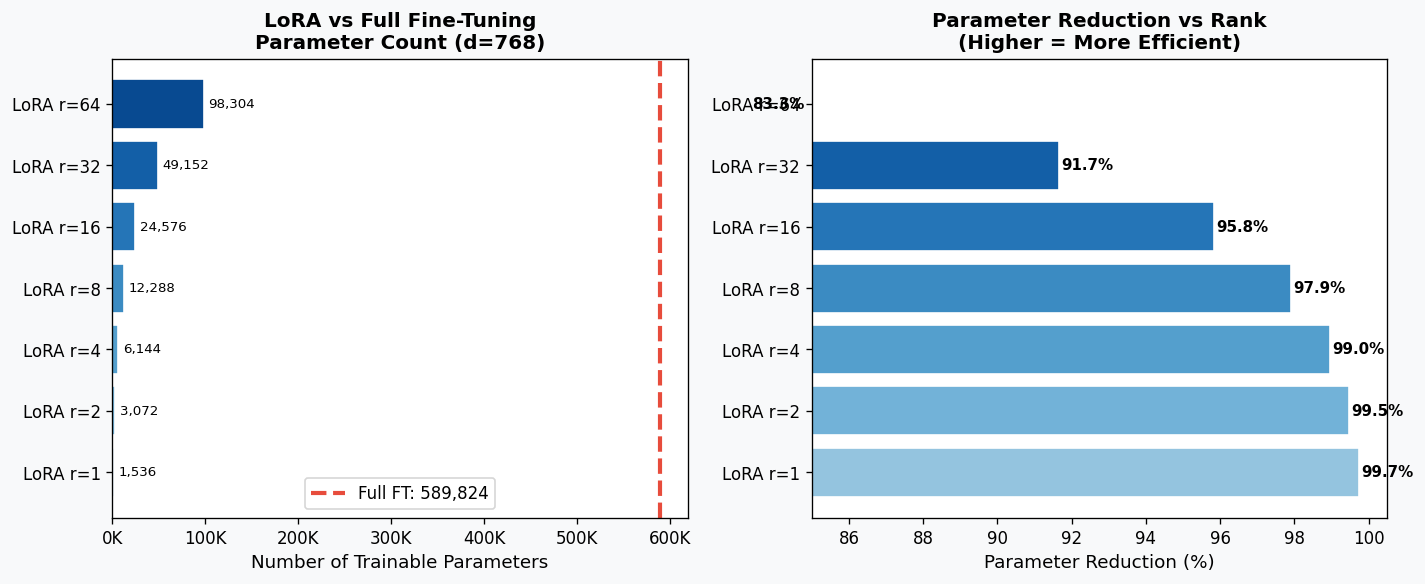

In [2]:
# ============================================================
# CELL: LoRA Math From Scratch (NumPy only — no model needed)
#
# We simulate what happens to a single weight matrix:
#   - Full fine-tuning: must update the whole matrix
#   - LoRA: only update two tiny matrices A and B
# ============================================================

# --- Setup dimensions (matching DistilBERT attention size) ---
d = 768   # weight matrix dimension (768 × 768 in DistilBERT)
r = 8     # LoRA rank — our chosen compression

print("=" * 55)
print("  LoRA Parameter Math Demo")
print("=" * 55)

# --- Full weight matrix ---
W_original = np.random.randn(d, d) * 0.02   # the frozen pre-trained weights
print(f"\nOriginal weight matrix W: shape = ({d}, {d})")

# --- Full fine-tuning: ΔW has same shape as W ---
delta_W_full = np.random.randn(d, d) * 0.01  # gradient update (full)
full_params = d * d
print(f"\n[Full Fine-Tuning]")
print(f"  ΔW shape      : ({d}, {d})")
print(f"  Parameters    : {d} × {d} = {full_params:,}")

# --- LoRA: decompose ΔW ≈ B × A ---
A = np.random.randn(r, d) * 0.01   # shape: (r, d) = (8, 768)
B = np.zeros((d, r))               # B initialized to zero (standard LoRA init)
# Note: B starts at zero so LoRA output = 0 at start → stable training
lora_params = r * d + d * r        # A + B
lora_alpha = 16
scaling = lora_alpha / r           # = 2.0 for alpha=16, r=8

print(f"\n[LoRA (r={r}, alpha={lora_alpha})]")
print(f"  A shape       : ({r}, {d})  → {r * d:,} params")
print(f"  B shape       : ({d}, {r})  → {d * r:,} params")
print(f"  Total LoRA    : {lora_params:,} params")
print(f"  Scaling factor: alpha/r = {lora_alpha}/{r} = {scaling:.1f}")

# --- Compute the approximated update ---
delta_W_lora = (B @ A) * scaling   # LoRA approximation of ΔW
print(f"\n  ΔW via LoRA   : B@A shape = {delta_W_lora.shape}")

# --- Compare ---
reduction = (1 - lora_params / full_params) * 100
print(f"\n{'─'*45}")
print(f"  Full fine-tune params : {full_params:>10,}")
print(f"  LoRA params (r={r})    : {lora_params:>10,}")
print(f"  Parameter reduction   : {reduction:>9.1f}%")
print(f"  Compression ratio     : {full_params / lora_params:>9.0f}×")
print(f"{'─'*45}")

# --- For multiple ranks ---
print("\n  Rank comparison for d=768:")
print(f"  {'Rank':>6} | {'LoRA Params':>12} | {'Reduction':>10} | {'Ratio':>8}")
print(f"  {'─'*6}─┼─{'─'*12}─┼─{'─'*10}─┼─{'─'*8}")
for rank in [1, 2, 4, 8, 16, 32, 64]:
    p = 2 * rank * d
    red = (1 - p / full_params) * 100
    ratio = full_params / p
    print(f"  {rank:>6} | {p:>12,} | {red:>9.1f}% | {ratio:>6.0f}×")

# ─── Plot: parameter count comparison ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#f8f9fa')

# Left: absolute counts
ranks = [1, 2, 4, 8, 16, 32, 64]
lora_counts = [2 * r_ * d for r_ in ranks]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(ranks)))

bars = ax1.barh([f'LoRA r={r_}' for r_ in ranks], lora_counts, color=colors, edgecolor='white')
ax1.axvline(full_params, color='#e74c3c', linewidth=2.5, linestyle='--', label=f'Full FT: {full_params:,}')
ax1.set_xlabel('Number of Trainable Parameters', fontsize=11)
ax1.set_title('LoRA vs Full Fine-Tuning\nParameter Count (d=768)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, count in zip(bars, lora_counts):
    ax1.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=8)

# Right: reduction percentage
reductions = [(1 - c / full_params) * 100 for c in lora_counts]
bars2 = ax2.barh([f'LoRA r={r_}' for r_ in ranks], reductions, color=colors, edgecolor='white')
ax2.set_xlabel('Parameter Reduction (%)', fontsize=11)
ax2.set_title('Parameter Reduction vs Rank\n(Higher = More Efficient)', fontsize=12, fontweight='bold')
ax2.set_xlim(85, 100.5)
for bar, red in zip(bars2, reductions):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{red:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('lora_param_comparison.png', dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("\nChart saved: lora_param_comparison.png")


Total documents: 400

Class distribution:
category
Compliance    80
IP            80
Contract      80
Litigation    80
HR            80

Sample document (Contract):
------------------------------------------------------------
NON-DISCLOSURE AGREEMENT. This Agreement is made by and between Smith LLC and Smith LLC. Each party may disclose Confidential Information to the other solely for the purpose of evaluating a potential business relationship. Confidential Information shall remain protected for a period of five (5) year...
------------------------------------------------------------

Sample document (Litigation):
------------------------------------------------------------
ARBITRATION DEMAND. Claimant hereby demands arbitration pursuant to the dispute resolution clause of the Agreement dated March 3, 2024. The dispute arises from Respondent's failure to deliver services as specified. Claimant seeks damages in the amount of $750,000. All disputes shall be resolved by b...
-------------


Chart saved: legal_docs_distribution.png


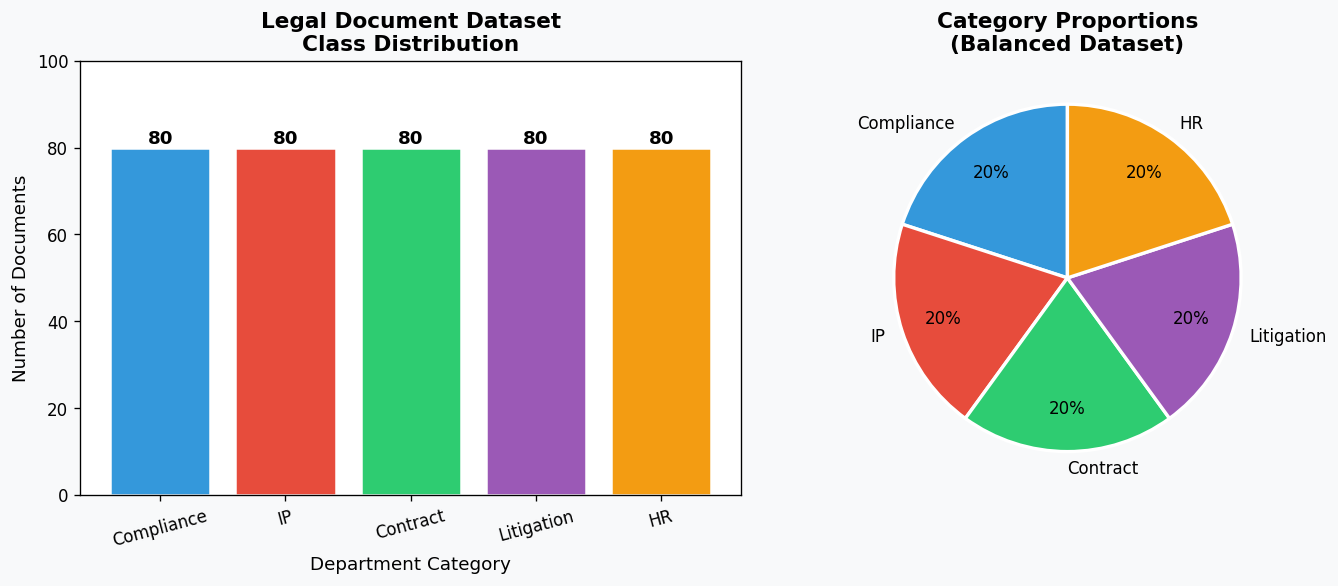

In [3]:
# ============================================================
# CELL: Generate Synthetic Legal Document Dataset
#
# We create 400 realistic legal document snippets across 5 classes.
# In a real project you'd use actual labeled documents — but for
# learning, synthetic data lets us control the experiment perfectly.
# ============================================================

import random
random.seed(SEED)

# ─── Templates for each legal document category ──────────────────────────────

CONTRACT_TEMPLATES = [
    "This Service Agreement ('Agreement') is entered into as of {date} between {party1} ('Client') and {party2} ('Vendor'). The Vendor agrees to provide software development services as detailed in Exhibit A. Payment terms: net 30 days from invoice.",
    "NON-DISCLOSURE AGREEMENT. This Agreement is made by and between {party1} and {party2}. Each party may disclose Confidential Information to the other solely for the purpose of evaluating a potential business relationship. Confidential Information shall remain protected for a period of five (5) years.",
    "MASTER SERVICES AGREEMENT. {party1} hereby engages {party2} to perform consulting services. The parties agree that all deliverables shall be work-for-hire. Contractor warrants that services will be performed in a professional manner consistent with industry standards.",
    "PURCHASE ORDER AGREEMENT. Buyer: {party1}. Seller: {party2}. The following goods shall be delivered FOB destination by {date}. Title and risk of loss pass to Buyer upon delivery. Seller warrants goods are free from defects in materials and workmanship for 12 months.",
    "LICENSE AGREEMENT. Licensor grants to Licensee a non-exclusive, non-transferable license to use the Software. Licensee may not sublicense, sell, resell, transfer, assign, or otherwise dispose of the Software. Annual license fee: USD {amount} payable in advance.",
    "VENDOR CONTRACT. This agreement governs the procurement of professional services. The contractor shall maintain general liability insurance of not less than $1,000,000 per occurrence. All work product created hereunder shall be deemed confidential and proprietary.",
    "AMENDMENT TO SERVICE AGREEMENT dated {date}. The parties agree to modify Section 4 (Payment Terms) to reflect revised milestone deliverables. All other terms and conditions of the original agreement remain in full force and effect.",
    "SUBSCRIPTION AGREEMENT. Client agrees to subscribe to the SaaS platform on a monthly basis. This agreement auto-renews unless cancelled with 30 days written notice. Data processing addendum is incorporated herein by reference.",
]

LITIGATION_TEMPLATES = [
    "IN THE UNITED STATES DISTRICT COURT. PLAINTIFF'S MOTION FOR SUMMARY JUDGMENT. Plaintiff {party1} moves this Court for summary judgment on all counts. There is no genuine dispute as to any material fact, and Plaintiff is entitled to judgment as a matter of law. Fed. R. Civ. P. 56.",
    "DEPOSITION OF {party2}. Q: Can you describe your role at the time of the incident? A: I was the Director of Operations. Q: Were you present during the board meeting on {date}? A: Yes, I attended via video conference. Q: What was discussed regarding the alleged contract breach?",
    "COMPLAINT FOR DAMAGES. Plaintiff brings this action against Defendant for breach of contract, negligence, and fraudulent misrepresentation. Plaintiff seeks compensatory damages exceeding $500,000, punitive damages, and attorney's fees pursuant to applicable statute.",
    "DEFENDANT'S ANSWER AND AFFIRMATIVE DEFENSES. Defendant admits the allegations in Paragraph 1. Defendant denies each and every allegation in Paragraphs 15-23. As its First Affirmative Defense, Defendant asserts the statute of limitations bars Plaintiff's claims.",
    "ORDER GRANTING PRELIMINARY INJUNCTION. Having considered the moving papers, opposition, and reply, this Court finds that Plaintiff has demonstrated: (1) likelihood of success on the merits; (2) irreparable harm; (3) balance of equities favors injunctive relief.",
    "ARBITRATION DEMAND. Claimant hereby demands arbitration pursuant to the dispute resolution clause of the Agreement dated {date}. The dispute arises from Respondent's failure to deliver services as specified. Claimant seeks damages in the amount of $750,000.",
    "MOTION TO DISMISS PURSUANT TO RULE 12(b)(6). Plaintiff's complaint fails to state a claim upon which relief can be granted. The allegations are conclusory and lack the factual specificity required by Twombly and Iqbal. Respectfully submitted for dismissal with prejudice.",
    "SETTLEMENT AGREEMENT AND MUTUAL RELEASE. In consideration of payment of {amount} by Defendant, Plaintiff releases all claims arising out of or related to the litigation. This settlement is not an admission of liability by any party.",
]

COMPLIANCE_TEMPLATES = [
    "ANNUAL COMPLIANCE REPORT — GDPR DATA PROTECTION. This report summarizes our data protection activities for the reporting period. We conducted 3 data protection impact assessments (DPIAs), responded to 47 data subject access requests, and reported 2 personal data breaches to the supervisory authority within 72 hours.",
    "SEC FORM 10-K FILING. RISK FACTORS: The Company faces significant regulatory scrutiny. Failure to comply with financial regulations could result in fines, sanctions, or loss of operating licenses. The Company maintains a robust compliance program overseen by the Chief Compliance Officer.",
    "AML COMPLIANCE MEMORANDUM. Pursuant to the Bank Secrecy Act and FinCEN regulations, this institution files Suspicious Activity Reports (SARs) for transactions exceeding $10,000 that appear to involve funds from illegal activity. KYC procedures were reviewed and updated.",
    "HIPAA PRIVACY AUDIT FINDINGS. Our annual HIPAA audit identified the following findings: (1) access controls for PHI need strengthening; (2) workforce training is current; (3) Business Associate Agreements are in place with all vendors. Risk level: Medium. Remediation timeline: 90 days.",
    "REGULATORY COMPLIANCE CERTIFICATION. We hereby certify that our operations comply with all applicable federal, state, and local regulations as of the date of this certification. Material compliance issues have been disclosed to the Board Audit Committee as required.",
    "DODD-FRANK COMPLIANCE REPORT. This report addresses our compliance with the Dodd-Frank Wall Street Reform and Consumer Protection Act. Stress testing results indicate adequate capital reserves. Volcker Rule compliance program is operational with no violations detected.",
    "FDA REGULATORY SUBMISSION. This 510(k) premarket notification demonstrates substantial equivalence of our medical device to a legally marketed predicate device. Clinical data and performance testing results are attached. We request expedited review.",
    "ENVIRONMENTAL COMPLIANCE AUDIT. Facility inspection conducted under the Clean Air Act, Clean Water Act, and RCRA. No violations found. Permit renewal applications filed 180 days in advance as required. Emissions data within all regulatory thresholds.",
]

IP_TEMPLATES = [
    "PATENT APPLICATION — US PATENT AND TRADEMARK OFFICE. CLAIMS: 1. A system for processing natural language queries comprising: a tokenization module configured to segment input text; a transformer-based encoder with attention mechanisms; and a classification head trained on domain-specific data.",
    "TRADEMARK APPLICATION. Mark: LEXISMART. Goods/Services: Legal research software, namely, artificial intelligence-based document analysis and classification services (Class 42). First use in commerce: {date}. Specimen: Screenshot of software interface attached.",
    "COPYRIGHT REGISTRATION. Title of Work: Legal Document Analysis Methodology. Nature of Authorship: Text and Software Code. Year of Completion: 2024. This work is an original expression of the author and is protected under 17 U.S.C. § 102.",
    "PATENT INFRINGEMENT ANALYSIS. Claim chart comparing U.S. Patent No. 10,XXX,XXX against Accused Product. Element-by-element analysis: Claim 1 preamble: SATISFIED. Limitation (a) tokenization: SATISFIED. Limitation (b) attention mechanism: SATISFIED. Opinion: Strong infringement case.",
    "INTELLECTUAL PROPERTY ASSIGNMENT AGREEMENT. Assignor hereby irrevocably assigns to Assignee all right, title, and interest in and to the following intellectual property: Patent Application Serial No. XX/XXX,XXX, all related trade secrets, and associated know-how.",
    "TRADE SECRET PROTECTION NOTICE. This document contains proprietary and confidential trade secret information of {party1}. Disclosure to unauthorized parties is strictly prohibited and may result in legal action. Recipient acknowledges obligations under the Defend Trade Secrets Act.",
    "DMCA TAKEDOWN NOTICE. Pursuant to 17 U.S.C. § 512(c)(3), we hereby notify you that the following content infringes our copyright. Please remove or disable access to the infringing material immediately. Our registered agent has verified this notice.",
    "IP DUE DILIGENCE REPORT. Review of target company's intellectual property portfolio: 12 issued patents, 4 pending applications, 23 registered trademarks. Freedom-to-operate analysis: No blocking third-party patents identified for core products. Recommendation: Proceed with acquisition.",
]

HR_TEMPLATES = [
    "EMPLOYMENT OFFER LETTER. We are pleased to extend an offer of employment for the position of Senior Legal Analyst. Compensation: $95,000 annual salary. Benefits: full health, dental, vision. Start date: {date}. This offer is contingent on background check clearance.",
    "TERMINATION LETTER — INVOLUNTARY SEPARATION. This letter serves as formal notice that your employment with {party1} is terminated effective {date}. Your separation is due to restructuring and is not related to your performance. Severance pay equivalent to 4 weeks will be provided.",
    "PERFORMANCE IMPROVEMENT PLAN (PIP). This PIP outlines expectations for improvement in the following areas: (1) meeting deadlines; (2) accuracy of legal research; (3) client communication. Review period: 90 days. Failure to meet targets may result in termination.",
    "EMPLOYEE SEPARATION AGREEMENT AND RELEASE. In consideration of severance pay totaling {amount}, Employee releases all claims against Employer including claims under Title VII, ADEA, ADA, and FMLA. Employee has 21 days to consider this agreement and 7 days to revoke.",
    "NON-COMPETE AND NON-SOLICITATION AGREEMENT. Employee agrees not to engage in competitive activities within a 50-mile radius for a period of 12 months following separation. Employee further agrees not to solicit any clients or employees of the Company during this period.",
    "WORKPLACE INVESTIGATION REPORT. This report summarizes the findings of an HR investigation into allegations of workplace harassment. Interviews conducted with 8 witnesses. Finding: allegations substantiated. Recommended action: termination of the respondent.",
    "FMLA LEAVE REQUEST APPROVAL. Your request for Family and Medical Leave Act leave has been approved for a period of up to 12 weeks beginning {date}. This leave is designated as FMLA-qualifying. Your position will be protected during your absence.",
    "EMPLOYEE HANDBOOK ACKNOWLEDGMENT. I acknowledge receipt of the Employee Handbook and understand it is not a contract of employment. I agree to comply with all company policies including the code of conduct, anti-harassment policy, and data security policy.",
]

# ─── Generate dataset ─────────────────────────────────────────────────────────

CATEGORIES = {
    0: ('Contract',    CONTRACT_TEMPLATES),
    1: ('Litigation',  LITIGATION_TEMPLATES),
    2: ('Compliance',  COMPLIANCE_TEMPLATES),
    3: ('IP',          IP_TEMPLATES),
    4: ('HR',          HR_TEMPLATES),
}

NUM_PER_CLASS = 80   # 80 × 5 = 400 total documents
LABEL_NAMES   = [CATEGORIES[i][0] for i in range(5)]

# Fill-in placeholders
PARTIES  = ['Acme Corp', 'Smith LLC', 'Jones & Partners', 'TechCo Inc', 'Global Ventures', 'Alpha Legal', 'Beta Holdings']
DATES    = ['January 15, 2024', 'March 3, 2024', 'June 20, 2024', 'September 1, 2023', 'November 30, 2023']
AMOUNTS  = ['$50,000', '$125,000', '$250,000', '$75,000', '$500,000']

docs, labels = [], []
for label_id, (category, templates) in CATEGORIES.items():
    for i in range(NUM_PER_CLASS):
        tmpl = templates[i % len(templates)]
        text = tmpl.format(
            party1  = random.choice(PARTIES),
            party2  = random.choice(PARTIES),
            date    = random.choice(DATES),
            amount  = random.choice(AMOUNTS),
        )
        # Add slight variation: append a unique sentence
        variations = [
            " This document supersedes all prior agreements.",
            " Jurisdiction: State of New York.",
            " Governing law: Federal law applies.",
            " All disputes shall be resolved by binding arbitration.",
            " This document was prepared by outside counsel.",
        ]
        text += random.choice(variations)
        docs.append(text)
        labels.append(label_id)

df = pd.DataFrame({'text': docs, 'label': labels, 'category': [LABEL_NAMES[l] for l in labels]})

# Shuffle
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total documents: {len(df)}")
print(f"\nClass distribution:")
print(df['category'].value_counts().to_string())
print(f"\nSample document (Contract):")
print("-" * 60)
print(df[df['category']=='Contract']['text'].iloc[0][:300] + "...")
print("-" * 60)
print(f"\nSample document (Litigation):")
print("-" * 60)
print(df[df['category']=='Litigation']['text'].iloc[0][:300] + "...")
print("-" * 60)

# ─── Plot class distribution ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#f8f9fa')

COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

# Bar chart
counts = df['category'].value_counts()
ax1.bar(counts.index, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
ax1.set_title('Legal Document Dataset\nClass Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Documents', fontsize=11)
ax1.set_xlabel('Department Category', fontsize=11)
for i, (cat, count) in enumerate(counts.items()):
    ax1.text(i, count + 1, str(count), ha='center', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.tick_params(axis='x', rotation=15)

# Pie chart
ax2.pie(counts.values, labels=counts.index, colors=COLORS, autopct='%1.0f%%',
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Category Proportions\n(Balanced Dataset)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('legal_docs_distribution.png', dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("\nChart saved: legal_docs_distribution.png")


## 📖 Lesson 4 — HuggingFace PEFT Library

### What is the PEFT Library?

HuggingFace's `peft` library wraps **any pre-trained model** with LoRA
(or other PEFT methods) in just a few lines of code.

```python
from peft import LoraConfig, get_peft_model, TaskType

# Step 1: Define the LoRA configuration
config = LoraConfig(
    r            = 8,           # rank — controls capacity
    lora_alpha   = 16,          # scaling factor (typically 2×r)
    target_modules = ['q_lin', 'v_lin'],  # which layers to inject LoRA into
    lora_dropout = 0.1,         # regularization
    task_type    = TaskType.SEQ_CLS  # sequence classification
)

# Step 2: Wrap your existing model — that's it!
peft_model = get_peft_model(base_model, config)

# Step 3: Train normally — PEFT handles the rest
peft_model.print_trainable_parameters()
# → trainable params: 741,893 || all params: 67,699,210 || trainable%: 1.10%
```

The PEFT library:
- **Freezes** all original model weights automatically
- **Injects** LoRA matrices at the specified layers
- **Handles** the forward pass modification (adding the LoRA side path)
- **Allows** saving only the tiny LoRA weights (not the full model!)

### Target Modules — Which Layers to Apply LoRA To

For DistilBERT, the attention matrices are named:
- `q_lin` — Query projection (most important for learning task patterns)
- `k_lin` — Key projection
- `v_lin` — Value projection (second most important)
- `out_lin` — Output projection

**Common practice:** Apply LoRA to `q_lin` and `v_lin` — this captures the most
task-relevant information with the fewest parameters.

### 📝 Note: Why Attention Matrices?
Research (Hu et al., 2021 — the original LoRA paper) found that modifying
the attention mechanism is the most effective place to inject LoRA.
The attention weights determine *what the model pays attention to*,
and that's exactly what needs to change for a new task.


In [4]:
# ============================================================
# CELL: Load DistilBERT and Wrap with LoRA
#
# DistilBERT is a compressed version of BERT:
#   - 6 transformer layers (vs BERT's 12)
#   - 66M parameters (vs BERT's 110M)
#   - 97% of BERT's performance at 60% of the size
#
# We add a 5-class classification head on top, then wrap with LoRA.
# ============================================================

from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType
import torch.nn as nn

print("Loading DistilBERT tokenizer and model...")

# Load tokenizer — converts text to token IDs
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load the base model with a 5-class classification head
base_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5,              # our 5 legal departments
    id2label={i: name for i, name in enumerate(LABEL_NAMES)},
    label2id={name: i for i, name in enumerate(LABEL_NAMES)},
)

# Count base model parameters BEFORE LoRA
total_base_params = sum(p.numel() for p in base_model.parameters())
print(f"\nBase model (DistilBERT + classifier head):")
print(f"  Total parameters: {total_base_params:,}")
print(f"  Memory (FP32)    : ~{total_base_params * 4 / 1e6:.1f} MB")

# ─── Configure LoRA ───────────────────────────────────────────────────────────
lora_config = LoraConfig(
    r              = 8,          # rank: each ΔW ≈ B×A where B is (768×8), A is (8×768)
    lora_alpha     = 16,         # scaling: effective LR for LoRA = lr × (alpha/r) = lr × 2
    target_modules = ['q_lin', 'v_lin'],  # inject into Query & Value attention matrices
    lora_dropout   = 0.1,        # 10% dropout for regularization
    bias           = 'none',     # don't add bias terms (saves params)
    task_type      = TaskType.SEQ_CLS,   # tells PEFT this is a classification task
)

# Wrap the base model — this is the magic one-liner
peft_model = get_peft_model(base_model, lora_config)

# ─── Count parameters ─────────────────────────────────────────────────────────
trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in peft_model.parameters())
frozen_params    = total_params - trainable_params

print(f"\n{'='*55}")
print(f"  PEFT Model Parameter Summary")
print(f"{'='*55}")
print(f"  Total parameters  : {total_params:>12,}")
print(f"  Frozen parameters : {frozen_params:>12,}  (original DistilBERT — not touched)")
print(f"  Trainable params  : {trainable_params:>12,}  (only LoRA matrices)")
print(f"  Trainable %       : {trainable_params/total_params*100:>11.2f}%")
print(f"  Memory for training: ~{trainable_params * 16 / 1e6:.1f} MB  (vs {total_params * 16 / 1e6:.0f} MB full FT)")
print(f"{'='*55}")

# ─── Show LoRA injection points ───────────────────────────────────────────────
print("\nWhere LoRA was injected (showing layer 0 as example):")
for name, module in peft_model.named_modules():
    if 'lora' in name.lower() and 'layer.0' in name and 'lora_A' in name:
        print(f"  + {name}: {module}")
    if 'lora' in name.lower() and 'layer.0' in name and 'lora_B' in name:
        print(f"  + {name}: {module}")

print("\n  (Same pattern repeated for all 6 transformer layers)")
print("\nModel ready for fine-tuning!")


Loading DistilBERT tokenizer and model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Base model (DistilBERT + classifier head):
  Total parameters: 66,957,317
  Memory (FP32)    : ~267.8 MB

  PEFT Model Parameter Summary
  Total parameters  :   67,699,210
  Frozen parameters :   66,957,317  (original DistilBERT — not touched)
  Trainable params  :      741,893  (only LoRA matrices)
  Trainable %       :        1.10%
  Memory for training: ~11.9 MB  (vs 1083 MB full FT)

Where LoRA was injected (showing layer 0 as example):
  + base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A: ModuleDict(
  (default): Linear(in_features=768, out_features=8, bias=False)
)
  + base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default: Linear(in_features=768, out_features=8, bias=False)
  + base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B: ModuleDict(
  (default): Linear(in_features=8, out_features=768, bias=False)
)
  + base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B.default: Linear(in_features=8, ou

In [5]:
# ============================================================
# CELL: Fine-Tuning Training Loop
#
# Standard PyTorch training loop, but because we used PEFT,
# the optimizer only touches the 741K LoRA parameters —
# not the 67M frozen DistilBERT weights.
#
# 2 epochs, batch_size=8, AdamW optimizer with warmup.
# ============================================================

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time

# ─── Tokenize all documents ───────────────────────────────────────────────────
print("Tokenizing 400 documents (max_length=128)...")
MAX_LEN = 128   # truncate to 128 tokens — fast on CPU

encodings = tokenizer(
    df['text'].tolist(),
    padding    = True,
    truncation = True,
    max_length = MAX_LEN,
    return_tensors = 'pt',
)

label_tensor = torch.tensor(df['label'].values, dtype=torch.long)

# ─── Train / Val / Test split: 70% / 15% / 15% ────────────────────────────────
idx = list(range(len(df)))
idx_trainval, idx_test = train_test_split(idx, test_size=0.15, random_state=SEED, stratify=df['label'])
idx_train, idx_val     = train_test_split(idx_trainval, test_size=0.15/0.85, random_state=SEED,
                                           stratify=df['label'].iloc[idx_trainval])

print(f"Dataset splits: train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}")

def make_loader(indices, shuffle=False, batch_size=8):
    input_ids      = encodings['input_ids'][indices]
    attention_mask = encodings['attention_mask'][indices]
    labels_        = label_tensor[indices]
    dataset = TensorDataset(input_ids, attention_mask, labels_)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 8
train_loader = make_loader(idx_train, shuffle=True,  batch_size=BATCH_SIZE)
val_loader   = make_loader(idx_val,   shuffle=False, batch_size=BATCH_SIZE)
test_loader  = make_loader(idx_test,  shuffle=False, batch_size=BATCH_SIZE)

# ─── Optimizer + Scheduler ────────────────────────────────────────────────────
# Only LoRA parameters are passed to the optimizer — frozen weights ignored
optimizer = torch.optim.AdamW(
    [p for p in peft_model.parameters() if p.requires_grad],
    lr           = 2e-4,   # higher LR is fine since LoRA is small
    weight_decay = 0.01,
)

NUM_EPOCHS  = 2
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = total_steps // 10   # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

# ─── Helper: evaluate accuracy ────────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    with torch.no_grad():
        for input_ids_, attn_mask_, labels_ in loader:
            outputs = model(input_ids=input_ids_, attention_mask=attn_mask_, labels=labels_)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels_).sum().item()
            total   += labels_.size(0)
    return total_loss / len(loader), correct / total

# ─── Training loop ─────────────────────────────────────────────────────────────
print("\nStarting LoRA fine-tuning...")
print(f"{'─'*60}")
print(f"  {'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val Acc':>8} | {'Time':>7}")
print(f"{'─'*60}")

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    peft_model.train()
    epoch_start = time.time()
    running_loss = 0.0

    for batch_idx, (input_ids_, attn_mask_, labels_) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = peft_model(input_ids=input_ids_, attention_mask=attn_mask_, labels=labels_)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(peft_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_acc = evaluate(peft_model, val_loader)
    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"  {epoch+1:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | {val_acc:>7.1%} | {epoch_time:>5.1f}s")

print(f"{'─'*60}")
print(f"\nFinal validation accuracy: {history['val_acc'][-1]:.1%}")
print("Training complete!")


Tokenizing 400 documents (max_length=128)...
Dataset splits: train=279, val=61, test=60

Starting LoRA fine-tuning...
────────────────────────────────────────────────────────────
   Epoch | Train Loss |  Val Loss |  Val Acc |    Time
────────────────────────────────────────────────────────────


       1 |     1.4555 |    1.1361 |   72.1% |  19.4s


       2 |     0.8476 |    0.6743 |   95.1% |  19.0s
────────────────────────────────────────────────────────────

Final validation accuracy: 95.1%
Training complete!


  Test Set Results
  Test Accuracy: 93.3%  (56/60 correct)

Detailed Classification Report:
              precision    recall  f1-score   support

    Contract       1.00      1.00      1.00        12
  Litigation       1.00      0.83      0.91        12
  Compliance       0.75      1.00      0.86        12
          IP       1.00      1.00      1.00        12
          HR       1.00      0.83      0.91        12

    accuracy                           0.93        60
   macro avg       0.95      0.93      0.94        60
weighted avg       0.95      0.93      0.94        60




Chart saved: lora_confusion_matrix.png


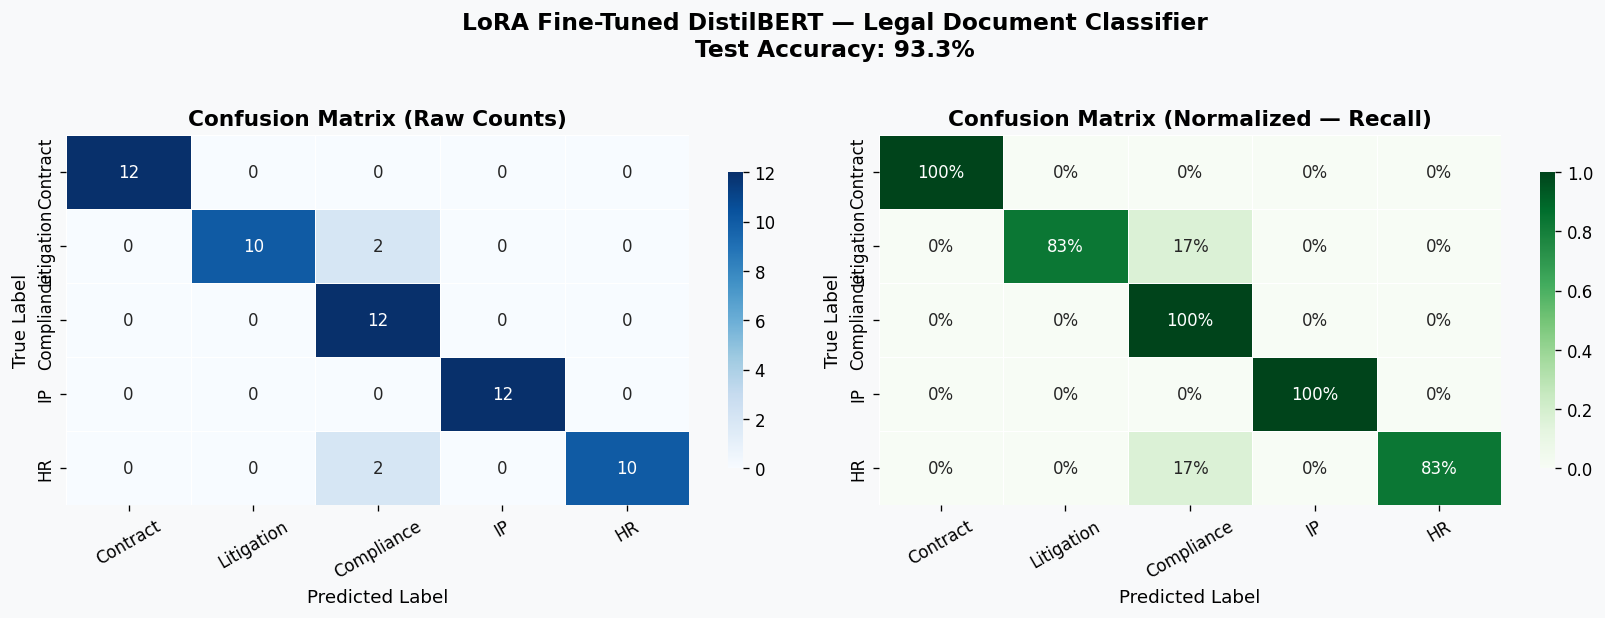

In [6]:
# ============================================================
# CELL: Evaluate on Test Set — Classification Report + Confusion Matrix
#
# The confusion matrix shows:
#   - Diagonal = correct predictions
#   - Off-diagonal = mistakes (which classes get confused)
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

# ─── Collect all predictions ──────────────────────────────────────────────────
peft_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids_, attn_mask_, labels_ in test_loader:
        outputs = peft_model(input_ids=input_ids_, attention_mask=attn_mask_)
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()

print(f"{'='*55}")
print(f"  Test Set Results")
print(f"{'='*55}")
print(f"  Test Accuracy: {test_acc:.1%}  ({(all_preds==all_labels).sum()}/{len(all_labels)} correct)")
print(f"{'='*55}")

# ─── Classification report ────────────────────────────────────────────────────
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

# ─── Confusion matrix plot ────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # normalize by row

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax1, cbar_kws={'shrink': 0.8})
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.tick_params(axis='x', rotation=30)

# Normalized (per-class recall)
sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Greens',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Confusion Matrix (Normalized — Recall)', fontsize=13, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=11)
ax2.tick_params(axis='x', rotation=30)

plt.suptitle(f'LoRA Fine-Tuned DistilBERT — Legal Document Classifier\nTest Accuracy: {test_acc:.1%}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lora_confusion_matrix.png', dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("\nChart saved: lora_confusion_matrix.png")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

───────────────────────────────────────────────────────────────────────────
  Method                 | Trainable Params | % of Total |  Mem (MB)
───────────────────────────────────────────────────────────────────────────
  Full Fine-Tuning       |       66,957,317 |    100.00% |  1071.3 MB
  Freeze All (Head Only) |          594,437 |      0.89% |     9.5 MB
  LoRA (r=4)             |          668,165 |      0.99% |    10.7 MB
  LoRA (r=8)             |          741,893 |      1.10% |    11.9 MB
  LoRA (r=16)            |          889,349 |      1.31% |    14.2 MB
───────────────────────────────────────────────────────────────────────────



Chart saved: peft_comparison.png


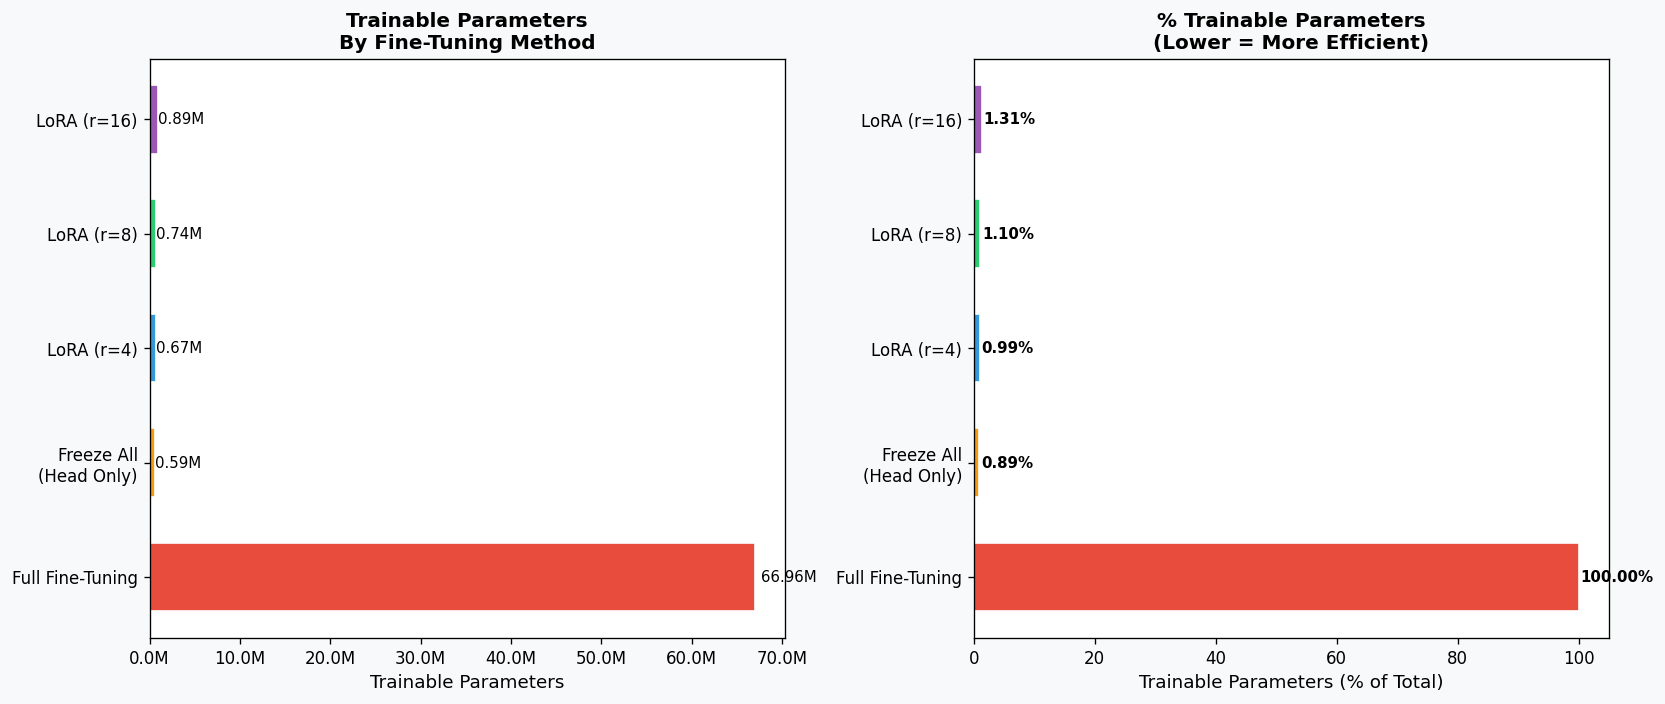

In [7]:
# ============================================================
# CELL: Compare Trainable Parameters Across Fine-Tuning Methods
#
# We instantiate several variants of DistilBERT with different
# configurations and count exactly how many parameters each
# method actually trains. Then visualize the comparison.
# ============================================================

from peft import LoraConfig, get_peft_model, TaskType
from transformers import DistilBertForSequenceClassification

results = []

# ─── Method 1: Full Fine-Tuning ───────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=5)
total  = sum(p.numel() for p in model.parameters())
trainable = total   # everything trained
results.append({
    'method': 'Full Fine-Tuning',
    'trainable': trainable,
    'total': total,
    'pct': 100.0,
    'memory_gb': total * 16 / 1e9,   # 16 bytes per param during training
    'color': '#e74c3c'
})

# ─── Method 2: Freeze all but classification head ─────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=5)
for name, param in model.named_parameters():
    if 'classifier' not in name and 'pre_classifier' not in name:
        param.requires_grad = False
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
results.append({
    'method': 'Freeze All\n(Head Only)',
    'trainable': trainable,
    'total': total,
    'pct': trainable / total * 100,
    'memory_gb': trainable * 16 / 1e9,
    'color': '#f39c12'
})

# ─── Methods 3–5: LoRA with r=4, 8, 16 ───────────────────────────────────────
for rank, color in [(4, '#3498db'), (8, '#2ecc71'), (16, '#9b59b6')]:
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=5)
    cfg = LoraConfig(r=rank, lora_alpha=16, target_modules=['q_lin','v_lin'],
                     lora_dropout=0.1, task_type=TaskType.SEQ_CLS)
    peft_m = get_peft_model(model, cfg)
    trainable = sum(p.numel() for p in peft_m.parameters() if p.requires_grad)
    ttl       = sum(p.numel() for p in peft_m.parameters())
    results.append({
        'method': f'LoRA (r={rank})',
        'trainable': trainable,
        'total': ttl,
        'pct': trainable / ttl * 100,
        'memory_gb': trainable * 16 / 1e9,
        'color': color
    })

# ─── Print table ──────────────────────────────────────────────────────────────
print(f"{'─'*75}")
print(f"  {'Method':<22} | {'Trainable Params':>16} | {'% of Total':>10} | {'Mem (MB)':>9}")
print(f"{'─'*75}")
for r in results:
    mem_mb = r['trainable'] * 16 / 1e6
    print(f"  {r['method'].replace(chr(10),' '):<22} | {r['trainable']:>16,} | {r['pct']:>9.2f}% | {mem_mb:>7.1f} MB")
print(f"{'─'*75}")

# ─── Plot: horizontal bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')

methods = [r['method'] for r in results]
trainables = [r['trainable'] for r in results]
pcts = [r['pct'] for r in results]
colors = [r['color'] for r in results]

# Left: absolute count
bars = axes[0].barh(methods, trainables, color=colors, edgecolor='white', height=0.6)
axes[0].set_xlabel('Trainable Parameters', fontsize=11)
axes[0].set_title('Trainable Parameters\nBy Fine-Tuning Method', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(bars, trainables):
    axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                 f'{val/1e6:.2f}M', va='center', fontsize=9)

# Right: percentage
bars2 = axes[1].barh(methods, pcts, color=colors, edgecolor='white', height=0.6)
axes[1].set_xlabel('Trainable Parameters (% of Total)', fontsize=11)
axes[1].set_title('% Trainable Parameters\n(Lower = More Efficient)', fontsize=12, fontweight='bold')
for bar, pct in zip(bars2, pcts):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('peft_comparison.png', dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("\nChart saved: peft_comparison.png")


## 📖 Lesson 5 — QLoRA: Fine-Tuning 7B Models on a Gaming GPU

### What is Quantization?

Quantization means using **fewer bits** to store each number.

```
FP32 (standard):  0.123456789  →  32 bits  (4 bytes)
FP16 (half):      0.1234       →  16 bits  (2 bytes)   → 2× savings
INT8:             0.12         →   8 bits  (1 byte)    → 4× savings
INT4:             0.1          →   4 bits  (0.5 bytes) → 8× savings
```

**Trade-off:** Less precision, but for LLMs, 4-bit quantization loses surprisingly little quality.

---

### The QLoRA Math (Dettmers et al., NeurIPS 2023)

```
Standard LLaMA-7B:
  7B params × 4 bytes (FP32) = 28 GB  ← needs A100

LLaMA-7B in 4-bit (QLoRA base):
  7B params × 0.5 bytes (INT4) = 3.5 GB  ← fits on gaming GPU!

+ LoRA adapters on top (FP16):
  70M params × 2 bytes = 0.14 GB

Total memory during QLoRA fine-tuning: ~6–8 GB
```

**This is revolutionary.** Before QLoRA (2023), fine-tuning LLaMA-7B required
multiple A100s (cost: ~$3/hour each). After QLoRA: a single RTX 3090 (cost: ~$500).

---

### Key Innovation: NF4 (NormalFloat 4-bit)

Regular INT4 quantization loses quality. QLoRA uses a specially designed
**NormalFloat 4-bit** data type that assumes weights follow a normal distribution
(which they do) and quantizes them more efficiently.

Additionally, QLoRA uses **double quantization** — even the quantization constants
are quantized, saving another ~0.37 bits per parameter.

---

### QLoRA Architecture

```
┌──────────────────────────────────────────────┐
│  Base Model (LLaMA-7B)                        │
│  ← Quantized to 4-bit (NF4)  ← FROZEN ❄️     │
│  Memory: 3.5 GB                               │
├──────────────────────────────────────────────┤
│  LoRA Adapters (A and B matrices)             │
│  ← Kept in BFloat16 (full precision)          │
│  ← Only these are trained ✅                   │
│  Memory: ~0.14 GB                             │
└──────────────────────────────────────────────┘
Total: ~4–8 GB depending on batch size / sequence length
```

### 📝 Note: Practical Impact
QLoRA made fine-tuning accessible to individuals and small teams.
Before 2023: only tech giants could fine-tune frontier models.
After QLoRA: a PhD student with a gaming PC can fine-tune LLaMA.
This democratized AI development significantly.


In [8]:
# ============================================================
# CELL: QLoRA Concept Code
#
# QLoRA requires bitsandbytes library AND a CUDA GPU.
# This cell shows the exact code you would use, but gracefully
# skips execution on CPU-only environments (like this notebook).
# ============================================================

try:
    import bitsandbytes as bnb
    from transformers import BitsAndBytesConfig
    import torch

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU not available — QLoRA requires CUDA")

    print("CUDA available! Running QLoRA demo...")

    # 4-bit quantization config — this is what makes QLoRA work
    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = True,       # quantize base model to 4-bit
        bnb_4bit_use_double_quant = True,       # quantize the quantization constants too (saves ~0.37 bits/param)
        bnb_4bit_quant_type       = 'nf4',      # NormalFloat4 — best for normally distributed weights
        bnb_4bit_compute_dtype    = torch.bfloat16,  # compute in BF16 for stability
    )

    # Load model with 4-bit quantization
    from transformers import AutoModelForCausalLM, AutoTokenizer
    model = AutoModelForCausalLM.from_pretrained(
        'meta-llama/Llama-2-7b-hf',     # 7B model
        quantization_config = bnb_config,
        device_map          = 'auto',    # auto-distribute across available GPUs
    )

    # Add LoRA on top of the quantized model
    from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training

    # IMPORTANT: call this before get_peft_model for quantized models
    model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r              = 16,
        lora_alpha     = 32,
        target_modules = ['q_proj', 'v_proj'],  # LLaMA uses different naming
        lora_dropout   = 0.05,
        bias           = 'none',
        task_type      = TaskType.CAUSAL_LM,
    )

    qlora_model = get_peft_model(model, lora_config)
    qlora_model.print_trainable_parameters()

except (ImportError, RuntimeError, Exception) as e:
    # This is expected on CPU-only systems
    print("=" * 60)
    print("  QLoRA Demo — CPU Environment Detected")
    print("=" * 60)
    print(f"  Reason: {e}")
    print()
    print("  QLoRA is not executed here, but here is what it does:")
    print()
    print("  1. Load model in 4-bit NF4 quantization")
    print("     7B × 0.5 bytes = 3.5 GB (vs 28 GB for FP32)")
    print()
    print("  2. Prepare model for k-bit training")
    print("     (casts LayerNorm to FP32, enables gradient checkpointing)")
    print()
    print("  3. Wrap with LoRA — only LoRA matrices stay in FP16")
    print("     Trainable params: ~70M of 7,000M = ~1%")
    print()
    print("  4. Total memory during training: ~6-8 GB")
    print("     → Fits on a single RTX 3090 (24 GB) or even RTX 3080 (10 GB)!")
    print()
    print("  On a GPU system, this cell would:")
    print("  - Download LLaMA-7B (~13 GB)")
    print("  - Quantize to 4-bit (~3.5 GB)")
    print("  - Add LoRA adapters (~0.14 GB)")
    print("  - Print trainable params: ~0.65% of total")
    print("=" * 60)


  QLoRA Demo — CPU Environment Detected
  Reason: No module named 'bitsandbytes'

  QLoRA is not executed here, but here is what it does:

  1. Load model in 4-bit NF4 quantization
     7B × 0.5 bytes = 3.5 GB (vs 28 GB for FP32)

  2. Prepare model for k-bit training
     (casts LayerNorm to FP32, enables gradient checkpointing)

  3. Wrap with LoRA — only LoRA matrices stay in FP16
     Trainable params: ~70M of 7,000M = ~1%

  4. Total memory during training: ~6-8 GB
     → Fits on a single RTX 3090 (24 GB) or even RTX 3080 (10 GB)!

  On a GPU system, this cell would:
  - Download LLaMA-7B (~13 GB)
  - Quantize to 4-bit (~3.5 GB)
  - Add LoRA adapters (~0.14 GB)
  - Print trainable params: ~0.65% of total


## 📖 Lesson 6 — Prefix Tuning & Prompt Tuning

### The Core Idea

Instead of modifying the model's weights at all, **prefix tuning** prepends
a set of **learned virtual tokens** to the input.

```
Normal input:
  [CLS] This contract defines the terms of... [SEP]

With Prefix Tuning (20 virtual tokens prepended):
  [V1][V2]...[V20][CLS] This contract defines the terms of... [SEP]
```

The virtual tokens [V1]...[V20] are **not real words** — they're floating-point
vectors that are initialized randomly and learned during training.
Everything else (the entire model) stays frozen.

---

### Analogy: The Expert Consultant

Think of prefix tuning like giving the model a briefing before each task:

- **Prompt engineering** (manual): "You are a legal document classifier. Classify the following document..."
  → Human-written, fixed, not optimized

- **Prefix tuning** (learned): Let the model learn what the "best briefing" looks like
  → Machine-optimized, task-specific, ~0.1% of parameters

---

### Comparison: LoRA vs Prefix Tuning

| Aspect | LoRA | Prefix Tuning |
|--------|------|---------------|
| What is modified | Weight matrices (A, B) | Input sequence (virtual tokens) |
| Parameters | ~0.5–1% | ~0.01–0.1% |
| Quality | Very Good | Good |
| Merging into base | Yes! (B×A added to W) | No (need to prepend at inference) |
| Sequence length overhead | None | +20–100 tokens per input |
| Works with frozen APIs | No | Yes (if API accepts prefix) |

### Prompt Tuning (Li & Liang, 2021)

Prompt tuning is an even simpler variant:
- Only adds soft tokens to the **input layer** (not all layers like prefix tuning)
- Even fewer parameters (~thousands)
- Approaches full fine-tuning quality only at large model scales (>10B params)

### 📝 Note: When to Use Prefix Tuning
Prefix tuning is ideal when you cannot modify the model itself — for example,
when using a proprietary model API. You control the prefix, not the weights.


In [9]:
# ============================================================
# CELL: Prefix Tuning Demo with DistilGPT-2
#
# We show how to set up prefix tuning using PEFT.
# DistilGPT-2 is a small 82MB model — fast to load.
# We demonstrate parameter counts but skip the full training
# loop (already showed that pattern with LoRA above).
# ============================================================

from transformers import AutoModelForCausalLM, AutoTokenizer, GPT2Config
from peft import PrefixTuningConfig, get_peft_model, TaskType

print("Loading DistilGPT-2 for Prefix Tuning demo...")

# Load DistilGPT-2 — the smallest GPT-2 variant (~82 MB)
gpt2_model = AutoModelForCausalLM.from_pretrained('distilgpt2')
gpt2_tokenizer = AutoTokenizer.from_pretrained('distilgpt2')

total_gpt2_params = sum(p.numel() for p in gpt2_model.parameters())
print(f"\nDistilGPT-2 base model:")
print(f"  Total parameters: {total_gpt2_params:,}")
print(f"  Model config    : {gpt2_model.config.n_layer} layers, "
      f"{gpt2_model.config.n_head} attention heads, "
      f"hidden dim={gpt2_model.config.n_embd}")

# ─── Configure Prefix Tuning ──────────────────────────────────────────────────
NUM_VIRTUAL_TOKENS = 20   # number of virtual tokens to prepend

prefix_config = PrefixTuningConfig(
    task_type          = TaskType.CAUSAL_LM,    # causal language modeling
    num_virtual_tokens = NUM_VIRTUAL_TOKENS,    # 20 learned tokens prepended
    encoder_hidden_size = gpt2_model.config.n_embd,  # must match model's hidden size
)

prefix_model = get_peft_model(gpt2_model, prefix_config)

# ─── Count parameters ─────────────────────────────────────────────────────────
trainable = sum(p.numel() for p in prefix_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in prefix_model.parameters())

print(f"\n{'='*55}")
print(f"  Prefix Tuning Parameter Summary")
print(f"{'='*55}")
print(f"  Total parameters  : {total:>12,}")
print(f"  Trainable params  : {trainable:>12,}  (the prefix embeddings)")
print(f"  Trainable %       : {trainable/total*100:>11.4f}%")
print(f"{'='*55}")

# ─── Show what the virtual tokens look like ───────────────────────────────────
print(f"\nPrefix Token Details:")
print(f"  Virtual tokens        : {NUM_VIRTUAL_TOKENS}")
print(f"  Hidden dimension      : {gpt2_model.config.n_embd}")
print(f"  Params per token      : {gpt2_model.config.n_embd:,}")
print(f"  Total prefix params   : {NUM_VIRTUAL_TOKENS} × {gpt2_model.config.n_embd} × (some layers) = {trainable:,}")

# ─── Compare: LoRA vs Prefix Tuning on same model ─────────────────────────────
from peft import LoraConfig
lora_model_gpt2 = get_peft_model(
    AutoModelForCausalLM.from_pretrained('distilgpt2'),
    LoraConfig(r=8, lora_alpha=16, task_type=TaskType.CAUSAL_LM,
               lora_dropout=0.1)
)
lora_trainable = sum(p.numel() for p in lora_model_gpt2.parameters() if p.requires_grad)

print(f"\n  Side-by-side comparison on DistilGPT-2:")
print(f"  {'Method':<20} | {'Trainable Params':>16} | {'% of Model':>10}")
print(f"  {'─'*20}─┼─{'─'*16}─┼─{'─'*10}")
print(f"  {'Full Fine-Tune':<20} | {total_gpt2_params:>16,} | {'100.0%':>10}")
print(f"  {'Prefix Tuning':<20} | {trainable:>16,} | {trainable/total_gpt2_params*100:>9.4f}%")
print(f"  {'LoRA (r=8)':<20} | {lora_trainable:>16,} | {lora_trainable/total_gpt2_params*100:>9.4f}%")

print("\nPrefix tuning trains EVEN FEWER parameters than LoRA!")
print("The trade-off: slightly lower quality, but almost zero overhead.")


Loading DistilGPT-2 for Prefix Tuning demo...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


DistilGPT-2 base model:
  Total parameters: 81,912,576
  Model config    : 6 layers, 12 attention heads, hidden dim=768

  Prefix Tuning Parameter Summary
  Total parameters  :   82,096,896
  Trainable params  :      184,320  (the prefix embeddings)
  Trainable %       :      0.2245%

Prefix Token Details:
  Virtual tokens        : 20
  Hidden dimension      : 768
  Params per token      : 768
  Total prefix params   : 20 × 768 × (some layers) = 184,320


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


  Side-by-side comparison on DistilGPT-2:
  Method               | Trainable Params | % of Model
  ─────────────────────┼──────────────────┼───────────
  Full Fine-Tune       |       81,912,576 |     100.0%
  Prefix Tuning        |          184,320 |    0.2250%
  LoRA (r=8)           |          147,456 |    0.1800%

Prefix tuning trains EVEN FEWER parameters than LoRA!
The trade-off: slightly lower quality, but almost zero overhead.


Chart saved: ultimate_comparison.png


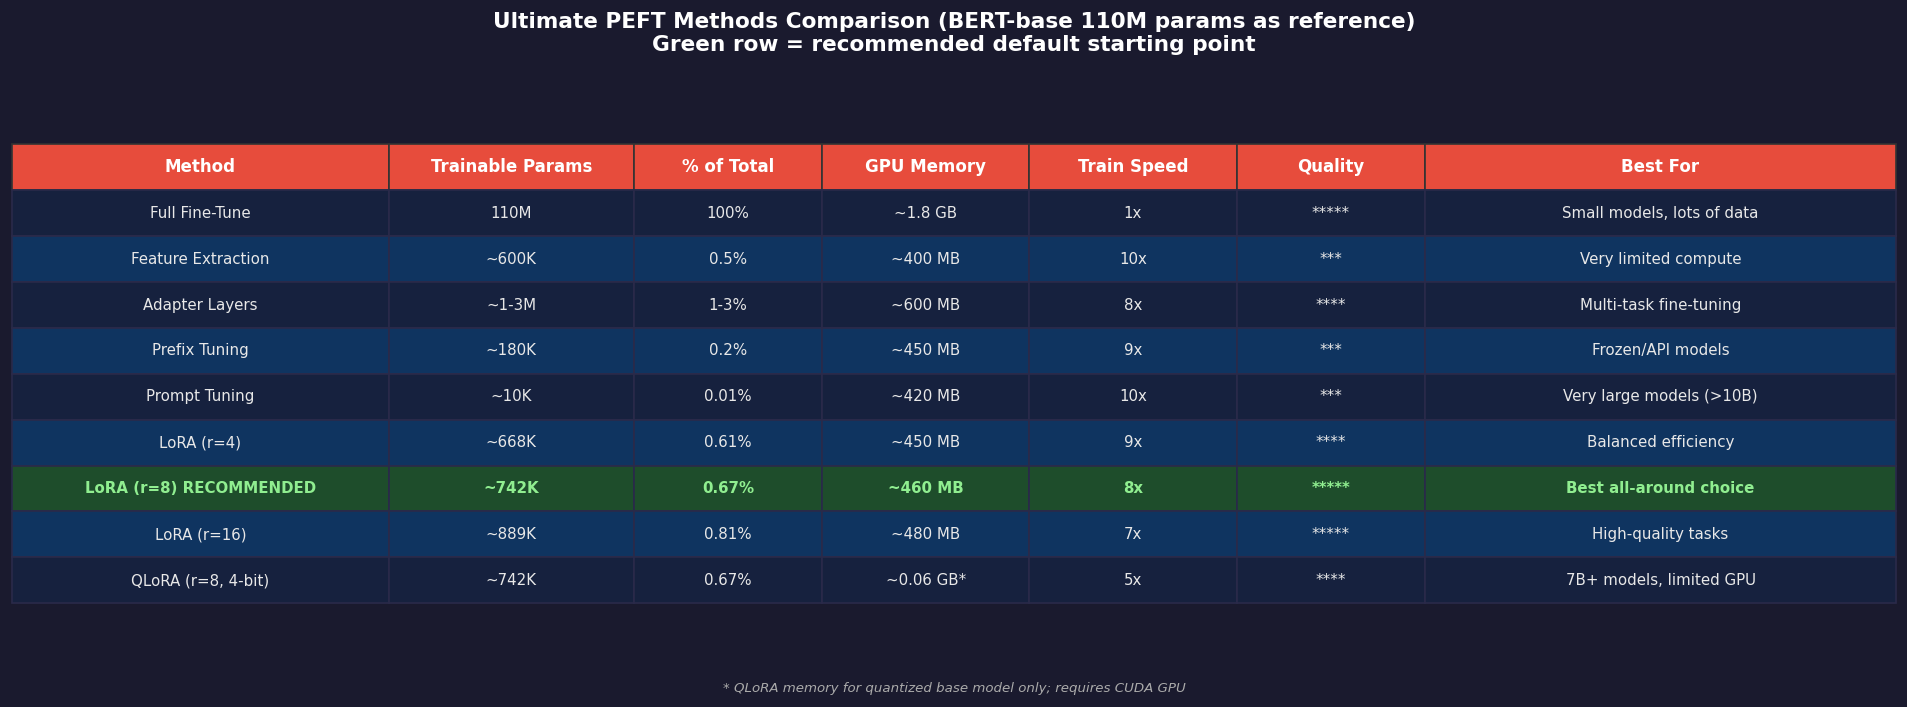

In [10]:
# ============================================================
# CELL: The Ultimate Comparison Table
# Visual summary of all fine-tuning methods as a matplotlib table.
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
ax.axis('off')

columns = ['Method', 'Trainable Params', '% of Total', 'GPU Memory', 'Train Speed', 'Quality', 'Best For']

data = [
    ['Full Fine-Tune',      '110M',     '100%',    '~1.8 GB',   '1x',  '*****', 'Small models, lots of data'],
    ['Feature Extraction',  '~600K',    '0.5%',    '~400 MB',   '10x', '***',   'Very limited compute'],
    ['Adapter Layers',      '~1-3M',    '1-3%',    '~600 MB',   '8x',  '****',  'Multi-task fine-tuning'],
    ['Prefix Tuning',       '~180K',    '0.2%',    '~450 MB',   '9x',  '***',   'Frozen/API models'],
    ['Prompt Tuning',       '~10K',     '0.01%',   '~420 MB',   '10x', '***',   'Very large models (>10B)'],
    ['LoRA (r=4)',          '~668K',    '0.61%',   '~450 MB',   '9x',  '****',  'Balanced efficiency'],
    ['LoRA (r=8) RECOMMENDED', '~742K', '0.67%',  '~460 MB',   '8x',  '*****', 'Best all-around choice'],
    ['LoRA (r=16)',         '~889K',    '0.81%',   '~480 MB',   '7x',  '*****', 'High-quality tasks'],
    ['QLoRA (r=8, 4-bit)',  '~742K',   '0.67%',   '~0.06 GB*', '5x',  '****',  '7B+ models, limited GPU'],
]

col_widths = [0.20, 0.13, 0.10, 0.11, 0.11, 0.10, 0.25]

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    colWidths=col_widths,
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.2)

for j in range(len(columns)):
    cell = table[0, j]
    cell.set_facecolor('#e74c3c')
    cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    cell.set_edgecolor('#333')

for i in range(len(data)):
    bg = '#16213e' if i % 2 == 0 else '#0f3460'
    for j in range(len(columns)):
        cell = table[i+1, j]
        cell.set_facecolor(bg)
        cell.set_text_props(color='#e8e8e8', fontsize=9)
        cell.set_edgecolor('#2a2a4a')

# Highlight LoRA r=8 row (recommended)
for j in range(len(columns)):
    table[7, j].set_facecolor('#1e4d2b')
    table[7, j].set_text_props(color='#90ee90', fontweight='bold')

ax.set_title(
    'Ultimate PEFT Methods Comparison (BERT-base 110M params as reference)\n'
    'Green row = recommended default starting point',
    fontsize=13, fontweight='bold', color='white', pad=20)

ax.text(0.5, -0.05,
        '* QLoRA memory for quantized base model only; requires CUDA GPU',
        transform=ax.transAxes, ha='center', color='#aaaaaa',
        fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('ultimate_comparison.png', dpi=120, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("Chart saved: ultimate_comparison.png")


## 📖 Lesson 7 — Enterprise Decision Guide

### Which Fine-Tuning Method Should You Use?

Use this flowchart to decide:

```
START: You need to fine-tune a model
           │
           ▼
    How big is your model?
    ┌──────────────────────────────────────────────────┐
    │  < 1B parameters (BERT, GPT-2, DistilBERT...)   │
    └──────────────────────────────────────────────────┘
           │
           ▼
    Do you have lots of labeled data (>100K examples)?
    ├── YES ──────────────────────────────────────────►  Full Fine-Tuning
    │                                                    Best quality, you can afford it
    └── NO
           │
           ▼
    Do you have GPU memory constraints (< 24 GB)?
    ├── NO (plenty of VRAM) ──────────────────────────►  LoRA r=8 or r=16
    │                                                    Best all-around PEFT choice
    └── YES (limited VRAM)
           │
           ▼
    Can you modify the model weights?
    ├── YES ─────────────────────────────────────────►   LoRA r=4 (minimal VRAM)
    │
    └── NO (API-only, proprietary model)
           │
           ▼
           ──────────────────────────────────────────►   Prefix Tuning or Prompt Tuning


    How big is your model?
    ┌──────────────────────────────────────────────────┐
    │  > 7B parameters (LLaMA, Mistral, Falcon...)     │
    └──────────────────────────────────────────────────┘
           │
           ▼
    Do you have a GPU with CUDA?
    ├── YES, 8–24 GB VRAM ───────────────────────────►   QLoRA (4-bit base + LoRA)
    ├── YES, 40–80 GB VRAM ──────────────────────────►   LoRA in FP16
    └── NO (CPU only) ───────────────────────────────►   Use a smaller model!
```

---

### Production Considerations

| Concern | Recommendation | Reason |
|---------|---------------|--------|
| **Inference latency** | LoRA (merged) | B×A can be added to W — zero overhead |
| **Multiple tasks** | LoRA (separate adapters) | Swap adapters at runtime, share base model |
| **Memory at inference** | Any PEFT | Save only adapter weights (~MB vs ~GB) |
| **Regulatory compliance** | Full fine-tune | Easier to audit and certify |
| **Rapid prototyping** | LoRA r=8 | Quick iteration, easy to experiment |
| **Edge deployment** | Quantized + LoRA | Minimize model size |

### 📝 Note: LoRA Weight Merging
One major advantage of LoRA over other PEFT methods:
after training, you can **merge the LoRA weights back** into the base model:

```python
merged_model = peft_model.merge_and_unload()
# Now merged_model is a regular model with NO extra overhead
# W_final = W_original + B @ A
```

The merged model runs exactly as fast as the original. Other methods
(prefix tuning, adapters) always require the extra components at inference.


## 📖 Lesson 8 — What Fine-Tuning Actually Changes

### The Four Levels of "Fine-Tuning"

These terms are often used loosely. Here's what each actually means:

---

#### Level 1: Feature Extraction (Freeze Everything, Just Add Head)
```
Pre-trained Model  ──────────────────────────────────────────────── (ALL FROZEN ❄️)
                                                                           │
                                                                    ┌──────▼──────┐
                                                                    │  New Head   │  ← TRAIN only this
                                                                    └─────────────┘
Trainable params: ~600K of 66M (0.9%)
```
**When:** You have very little data (<1K examples) and need to avoid overfitting.
**What changes:** Only the final classification layer learns task-specific patterns.
**Risk:** The model can't adapt its internal representations to your domain.

---

#### Level 2: Fine-Tune Top Layers (Partial Unfreeze)
```
Pre-trained Model
  Layer 1–4  ─────────────────────────────────────────────────── (FROZEN ❄️)
  Layer 5–6  ─────────────────────────────────────────────────── (TRAINED ✅)
  Head       ─────────────────────────────────────────────────── (TRAINED ✅)
```
**When:** Moderate data (1K–50K examples), domain is somewhat different from pre-training.
**What changes:** Higher layers (which encode more task-specific features) are updated.

---

#### Level 3: Full Fine-Tuning (Train Everything)
```
Pre-trained Model
  ALL Layers ─────────────────────────────────────────────────── (ALL TRAINED ✅)
  Head       ─────────────────────────────────────────────────── (TRAINED ✅)
```
**When:** Large dataset, ample compute, need maximum quality.
**What changes:** Every weight shifts toward the new task.
**Risk:** "Catastrophic forgetting" — model may lose general capabilities.

---

#### Level 4: PEFT Methods (Targeted Small Updates)
```
Pre-trained Model
  ALL Layers ─────────────────────────────────────────────────── (FROZEN ❄️)
  LoRA A/B   ─────────────────────────────────────────────────── (TRAINED ✅, tiny)
  Head       ─────────────────────────────────────────────────── (TRAINED ✅)
```
**When:** Limited compute, large model, good quality needed.
**What changes:** Only the low-rank adapter matrices, plus the head.
**Advantage:** Original knowledge is preserved (frozen weights unchanged).

---

### Enterprise Use Cases

| Use Case | Recommended Level | Why |
|----------|------------------|-----|
| Legal document classification (our demo) | LoRA (Level 4) | Limited data, need to preserve language understanding |
| Medical imaging report generation | Full FT (Level 3) | Domain very different from pre-training |
| Customer service chatbot | QLoRA (Level 4) | Large model needed, limited GPU budget |
| Code completion for a new language | Full FT (Level 3) | Syntax patterns very different |
| Sentiment analysis (many reviews) | Fine-tune top layers (Level 2) | Sufficient data, task is close to pre-training |
| Domain-specific named entity recognition | LoRA (Level 4) | Standard NER, PEFT works well |
| Novel language (low-resource) | Full FT (Level 3) | Need to learn new vocabulary patterns |
| Multi-task production system | LoRA per task (Level 4) | Shared base, separate adapters per task |


## 🎓 Module 04 Summary — Complete PEFT Recap

### What We Covered

| Lesson | Key Takeaway |
|--------|--------------|
| 1 — The Problem | Full fine-tuning needs 16× bytes per parameter — 7B params = 112 GB |
| 2 — PEFT Overview | Freeze most weights, train only 0.1–1% — same quality, tiny cost |
| 3 — LoRA Math | ΔW ≈ B×A where rank r << d — 97.9% parameter reduction at r=8 |
| 4 — PEFT Library | 3 lines of code to wrap any model with LoRA |
| 5 — QLoRA | 4-bit quantization + LoRA = 7B fine-tuning on a gaming GPU |
| 6 — Prefix Tuning | Learn virtual tokens instead of weights — 0.2% parameters |
| 7 — Decision Guide | Default choice: LoRA r=8. GPU limited: QLoRA. API-only: Prefix |
| 8 — What Changes | 4 levels from "freeze all" to "train all" — choose based on data/compute |

---

### 🔑 Key Numbers to Remember

```
Full fine-tuning a 7B model:
  Memory needed:    112 GB (7B × 16 bytes)
  Cost:             2–4 × A100 GPUs (~$8–12/hour on cloud)

LoRA fine-tuning a 7B model:
  Trainable params: ~70M (1% of 7B)
  Memory needed:    ~14 GB (with gradient checkpointing)
  Cost:             1 × A100 GPU (~$3/hour on cloud)

QLoRA fine-tuning a 7B model:
  Base model memory: 3.5 GB (4-bit quantized)
  Total memory:      6–8 GB
  Cost:              1 × RTX 3090 gaming GPU ($500 one-time)
```

---

### 💼 Interview Q&A

**Q1: What is LoRA and how does it reduce memory requirements?**
A: LoRA (Low-Rank Adaptation) freezes all pre-trained weights and injects trainable rank decomposition matrices (A and B) at each selected layer. Instead of updating a full d×d weight matrix (d² parameters), it learns two small matrices: A (r×d) and B (d×r), totaling only 2rd parameters. For d=768, r=8: 589,824 → 12,288 params (97.9% reduction). Memory drops because gradients and optimizer states only need to be stored for the small LoRA matrices, not the full model.

**Q2: What is the difference between LoRA and QLoRA?**
A: LoRA adds low-rank adapters to a full-precision (FP16/FP32) frozen model. QLoRA additionally quantizes the base model to 4-bit (NF4 format), reducing its memory footprint by 8×. The LoRA adapters still run in higher precision (BF16). QLoRA enables fine-tuning 7B+ models on consumer GPUs, while LoRA alone still requires high-end hardware for large models.

**Q3: Why can LoRA weights be merged but prefix tuning weights cannot?**
A: LoRA modifies weight matrices: W_new = W_orig + B×A. This can be precomputed once and stored as a single modified weight matrix — no runtime overhead. Prefix tuning prepends virtual token embeddings to the input sequence, which changes the computation graph at every forward pass. These tokens must be present at inference time; they cannot be absorbed into a single matrix operation.

**Q4: When would you choose full fine-tuning over LoRA?**
A: Full fine-tuning is preferred when: (1) the target domain is very different from pre-training data (e.g., specialized medical or legal jargon the model has never seen); (2) you have a large labeled dataset (>100K examples) to justify training all parameters; (3) you need maximum possible performance and have the GPU budget; (4) the model is small enough that compute cost isn't a constraint (e.g., BERT-base at 110M params is cheap to fully fine-tune).

---

### 📦 Files Generated This Notebook

| File | Description |
|------|-------------|
| `lora_param_comparison.png` | LoRA vs full fine-tuning parameter counts across ranks |
| `legal_docs_distribution.png` | Dataset class distribution |
| `lora_confusion_matrix.png` | Test set evaluation on legal document classifier |
| `peft_comparison.png` | Trainable params across fine-tuning methods |
| `ultimate_comparison.png` | All methods side-by-side comparison table |

---

### 🔮 Module 05 Preview — RLHF: Making Models Actually Helpful

Fine-tuning teaches a model to perform a task. But it doesn't teach the model
to be *helpful*, *honest*, or *harmless*. A fine-tuned model might still:

- Hallucinate confidently
- Give harmful instructions
- Refuse helpful requests

This is where **Reinforcement Learning from Human Feedback (RLHF)** comes in.

**What you'll learn in Module 05:**

1. **The reward model** — a neural network trained on human preferences
   (which response do humans prefer: A or B?)

2. **PPO (Proximal Policy Optimization)** — the RL algorithm that updates
   the LLM based on reward signals

3. **The RLHF pipeline:**
   ```
   Step 1: Supervised Fine-Tune (SFT) ← what we did in Module 04
   Step 2: Train Reward Model on human comparisons
   Step 3: RL fine-tune with PPO using reward model as signal
   ```

4. **Constitutional AI (CAI)** — Anthropic's approach to RLHF

5. **DPO (Direct Preference Optimization)** — a simpler alternative to RLHF
   that skips the reward model entirely

This is how ChatGPT, Claude, and Gemini go from "capable language models"
to "assistant that actually tries to be helpful."

---

*Module 04 Complete — PEFT methods mastered!*
*Proceed to Module 05: RLHF and Alignment*
